<a href="https://colab.research.google.com/github/SamrudhiDubal/Samrudhi-Dubal/blob/claude%2Fjob-portal-ai-resume-screening-1a4dp9/AI_Job_Assistance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your Talent Recruitment CSV dataset:


Saving Talent Recruitment Dataset.zip to Talent Recruitment Dataset.zip

Dataset successfully loaded!
Dataset Shape: (12000, 26)


,Candidate_ID,Gender,Age,Location,Highest_Degree,Specialization,CGPA,Experience_Years,Current_Role,Preferred_Job_Title,...,Technical_Skills,Certifications,Communication_Score,Leadership_Score,Problem_Solving_Score,Resume_Score,Job_Applications_Count,Interview_Attempts,Recruiter_Rating,Target_Category
0,CHN_CND_00001,Male,27,Tianjin,Diploma,Artificial Intelligence,8.33,15.9,Data Analyst,Data Scientist,...,"Python, Leadership, Communication, Cyber Security",Huawei HCIA,72.29,55.00,72.96,66.69,40,7,3.60,Highly Suitable
1,CHN_CND_00002,Female,41,Chengdu,MBA,Software Engineering,6.71,19.4,Cloud Engineer,DevOps Engineer,...,"Deep Learning, Cyber Security, Data Analysis, ...",Tencent Cloud,59.17,65.21,76.24,71.60,49,9,1.19,Moderately Suitable
2,CHN_CND_00003,Female,36,Tianjin,MBA,IoT Engineering,7.49,4.7,Cloud Engineer,Data Scientist,...,"NodeJS, Leadership, Java, NLP, TensorFlow, Tab...","Huawei HCIA, Oracle",99.16,73.34,93.00,84.02,9,6,1.05,Highly Suitable
3,CHN_CND_00004,Female,34,Guangzhou,Associate Degree,Cloud Computing,8.67,16.2,AI Engineer,Backend Developer,...,"Kubernetes, Leadership, NLP, Docker",Cisco,72.01,56.10,74.76,51.72,14,0,2.04,Moderately Suitable
4,CHN_CND_00005,Female,28,Guangzhou,Associate Degree,Human Resources,8.21,15.1,Cyber Security Analyst,Business Consultant,...,"Communication, Alibaba Cloud, Java, NodeJS, Cy...","Huawei HCIA, Scrum Master",51.57,92.11,72.49,69.76,36,7,3.28,Less Suitable



================ DATA INFORMATION ================

Rows: 12000
Columns: 26

Column Names:
['Candidate_ID', 'Gender', 'Age', 'Location', 'Highest_Degree', 'Specialization', 'CGPA', 'Experience_Years', 'Current_Role', 'Preferred_Job_Title', 'Industry', 'Company_Name', 'Current_Salary_CNY_K', 'Expected_Salary_CNY_K', 'Preferred_Work_Mode', 'Career_Level', 'Technical_Skills', 'Certifications', 'Communication_Score', 'Leadership_Score', 'Problem_Solving_Score', 'Resume_Score', 'Job_Applications_Count', 'Interview_Attempts', 'Recruiter_Rating', 'Target_Category']

Missing Values:


,0
Candidate_ID,0
Gender,0
Age,0
Location,0
Highest_Degree,0
Specialization,0
CGPA,0
Experience_Years,0
Current_Role,0
Preferred_Job_Title,0



Duplicate Records: 0

Shape after removing duplicates: (12000, 26)

Target Distribution:


,count
Target_Category,
Highly Suitable,4114
Less Suitable,3999
Moderately Suitable,3887


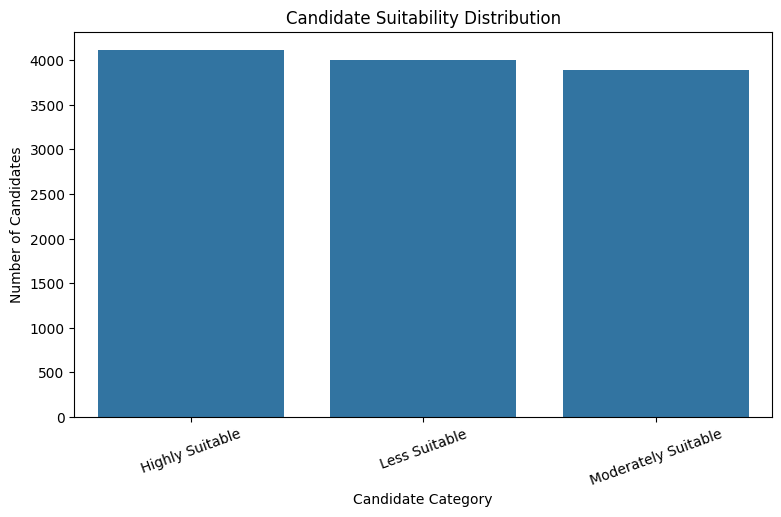


Numerical Columns:
['Age', 'CGPA', 'Experience_Years', 'Current_Salary_CNY_K', 'Expected_Salary_CNY_K', 'Communication_Score', 'Leadership_Score', 'Problem_Solving_Score', 'Resume_Score', 'Job_Applications_Count', 'Interview_Attempts', 'Recruiter_Rating']


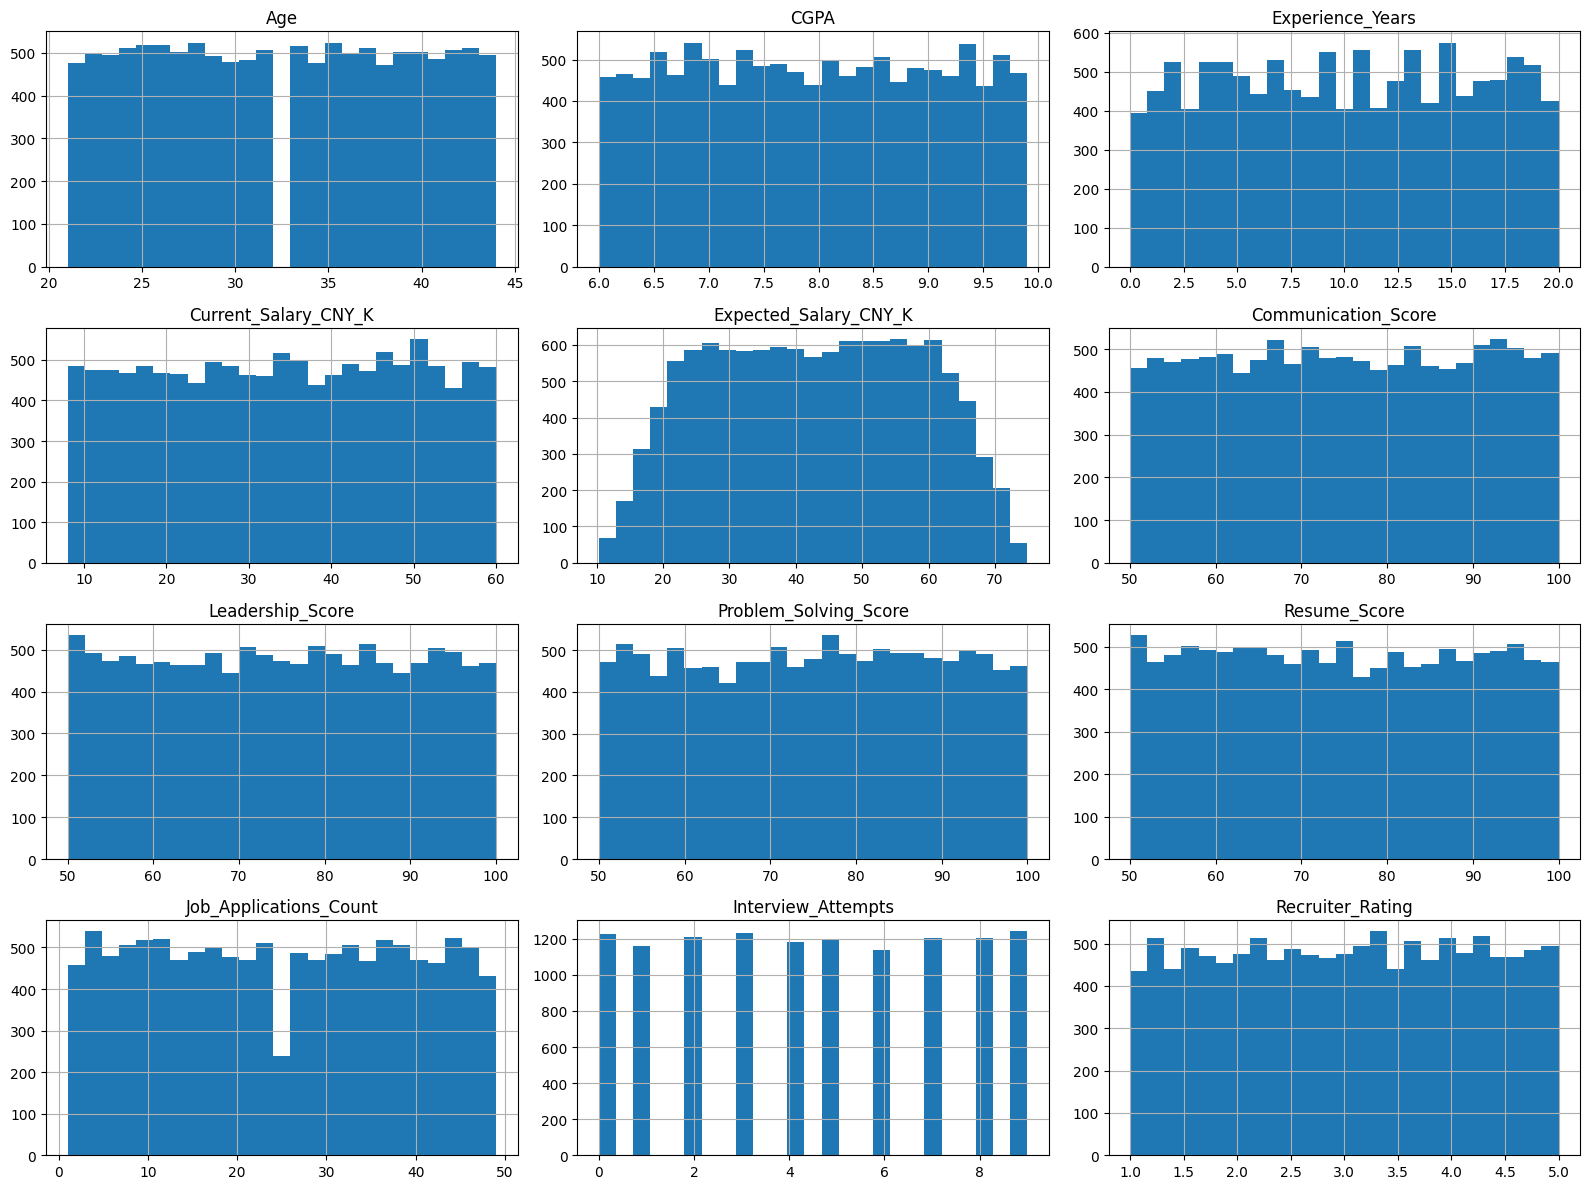

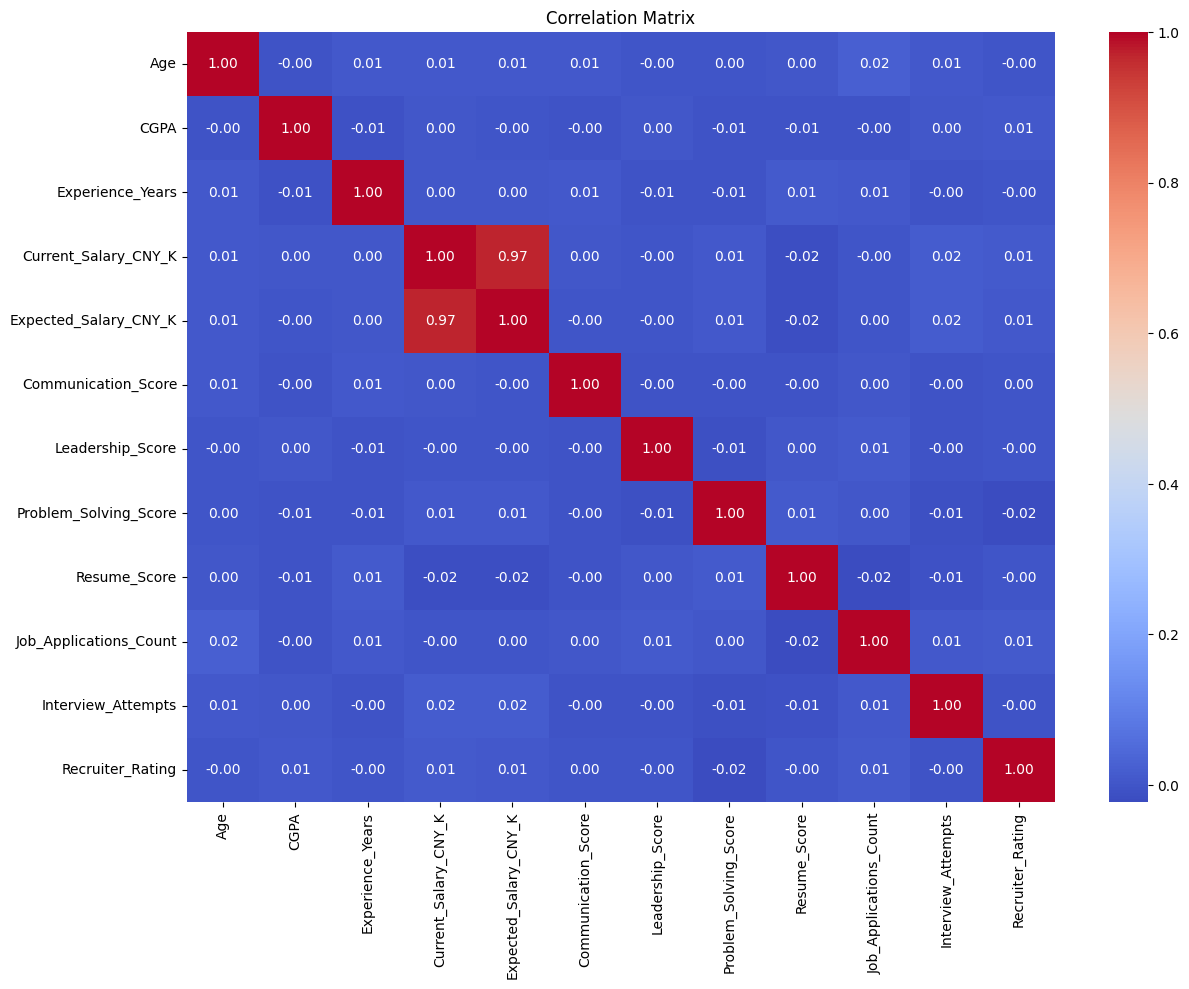


Feature Matrix: (12000, 24)
Target: (12000,)

Training Records: 9600
Testing Records: 2400

Categorical Features:
['Gender', 'Location', 'Highest_Degree', 'Specialization', 'Current_Role', 'Preferred_Job_Title', 'Industry', 'Company_Name', 'Preferred_Work_Mode', 'Career_Level', 'Technical_Skills', 'Certifications']

Numerical Features:
['Age', 'CGPA', 'Experience_Years', 'Current_Salary_CNY_K', 'Expected_Salary_CNY_K', 'Communication_Score', 'Leadership_Score', 'Problem_Solving_Score', 'Resume_Score', 'Job_Applications_Count', 'Interview_Attempts', 'Recruiter_Rating']

Training Random Forest Model...


In [ ]:
# ============================================================
# AI-BASED INTELLIGENT JOB ASSISTANCE & CANDIDATE MATCHING
# SRM UNIVERSITY - MBA AI & DATA SCIENCE PROJECT
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 2. UPLOAD DATASET
# ============================================================

print("Please upload your Talent Recruitment CSV dataset:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("\nDataset successfully loaded!")
print("Dataset Shape:", df.shape)

display(df.head())

# ============================================================
# 3. BASIC DATA INFORMATION
# ============================================================

print("\n================ DATA INFORMATION ================")

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate Records:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)

# ============================================================
# 4. TARGET COLUMN
# ============================================================

TARGET = "Target_Category"

if TARGET not in df.columns:
    print("\nERROR: Target_Category column was not found.")
    print("Available columns:")
    print(df.columns.tolist())
    raise ValueError("Target_Category column is required.")

print("\nTarget Distribution:")
display(df[TARGET].value_counts())

# ============================================================
# 5. EXPLORATORY DATA ANALYSIS
# ============================================================

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x=TARGET,
    order=df[TARGET].value_counts().index
)

plt.title("Candidate Suitability Distribution")
plt.xlabel("Candidate Category")
plt.ylabel("Number of Candidates")
plt.xticks(rotation=20)
plt.show()

# ============================================================
# 6. NUMERICAL FEATURE ANALYSIS
# ============================================================

numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

if len(numeric_columns) > 0:

    print("\nNumerical Columns:")
    print(numeric_columns)

    df[numeric_columns].hist(
        figsize=(16,12),
        bins=25
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 7. CORRELATION ANALYSIS
# ============================================================

if len(numeric_columns) > 1:

    plt.figure(figsize=(14,10))

    correlation = df[numeric_columns].corr()

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title("Correlation Matrix")
    plt.show()

# ============================================================
# 8. REMOVE IDENTIFIER / TARGET
# ============================================================

drop_columns = [TARGET]

# Candidate_ID is an identifier, not a predictive feature
if "Candidate_ID" in df.columns:
    drop_columns.append("Candidate_ID")

X = df.drop(columns=drop_columns)
y = df[TARGET]

print("\nFeature Matrix:", X.shape)
print("Target:", y.shape)

# ============================================================
# 9. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Records:", len(X_train))
print("Testing Records:", len(X_test))

# ============================================================
# 10. IDENTIFY DATA TYPES
# ============================================================

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

# ============================================================
# 11. DATA PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

# ============================================================
# 12. RANDOM FOREST MODEL
# ============================================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

print("\nTraining Random Forest Model...")

model.fit(X_train, y_train)

print("Model Training Completed!")

# ============================================================
# 13. PREDICTION
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# 14. MODEL PERFORMANCE
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n================================================")
print("MODEL PERFORMANCE")
print("================================================")

print("\nAccuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Candidate Suitability Confusion Matrix")

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.show()

# ============================================================
# 16. FEATURE IMPORTANCE
# ============================================================

print("\n================================================")
print("FEATURE IMPORTANCE")
print("================================================")

trained_preprocessor = model.named_steps["preprocessor"]

classifier = model.named_steps["classifier"]

feature_names = trained_preprocessor.get_feature_names_out()

importance = classifier.feature_importances_

feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

}).sort_values(
    by="Importance",
    ascending=False
)

display(
    feature_importance.head(20)
)

# Plot top 20 features

top_features = feature_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Features Influencing Candidate Suitability"
)

plt.show()

# ============================================================
# 17. CANDIDATE PREDICTION FUNCTION
# ============================================================

def predict_candidate(candidate_data):

    candidate_df = pd.DataFrame([candidate_data])

    prediction = model.predict(candidate_df)[0]

    probability = model.predict_proba(candidate_df)[0]

    probability_df = pd.DataFrame({

        "Category": model.classes_,

        "Probability": probability

    }).sort_values(
        by="Probability",
        ascending=False
    )

    return prediction, probability_df


# ============================================================
# 18. CREATE NEW CANDIDATE AUTOMATICALLY
# ============================================================

print("\n================================================")
print("NEW CANDIDATE PREDICTION")
print("================================================")

# Create candidate using median/mode values from dataset
# so the code works with the uploaded dataset.

new_candidate = {}

for column in X.columns:

    if column in numerical_features:

        new_candidate[column] = X[column].median()

    elif column in categorical_features:

        mode_value = X[column].mode()

        if len(mode_value) > 0:
            new_candidate[column] = mode_value.iloc[0]
        else:
            new_candidate[column] = "Unknown"

prediction, probability = predict_candidate(
    new_candidate
)

print("\nPredicted Candidate Category:")
print(">>>", prediction)

print("\nPrediction Probability:")

display(probability)

# ============================================================
# 19. SIMPLE JOB MATCHING SYSTEM
# ============================================================

print("\n================================================")
print("JOB MATCHING SYSTEM")
print("================================================")

def job_matching(candidate, jobs):

    results = []

    for index, job in jobs.iterrows():

        score = 0

        # Experience Match
        if (
            "Experience_Years" in candidate
            and "Experience_Years" in job
        ):

            if candidate["Experience_Years"] >= job["Experience_Years"]:
                score += 25

        # Degree Match
        if (
            "Highest_Degree" in candidate
            and "Highest_Degree" in job
        ):

            if str(candidate["Highest_Degree"]).lower() == \
               str(job["Highest_Degree"]).lower():

                score += 20

        # Industry Match
        if (
            "Industry" in candidate
            and "Industry" in job
        ):

            if str(candidate["Industry"]).lower() == \
               str(job["Industry"]).lower():

                score += 20

        # Job Title Match
        if (
            "Preferred_Job_Title" in candidate
            and "Job_Title" in job
        ):

            if str(candidate["Preferred_Job_Title"]).lower() \
               in str(job["Job_Title"]).lower():

                score += 25

        # Work Mode Match
        if (
            "Preferred_Work_Mode" in candidate
            and "Work_Mode" in job
        ):

            if str(candidate["Preferred_Work_Mode"]).lower() == \
               str(job["Work_Mode"]).lower():

                score += 10

        results.append(score)

    output = jobs.copy()

    output["Match_Score"] = results

    output = output.sort_values(
        by="Match_Score",
        ascending=False
    )

    return output


# ============================================================
# 20. DEMO JOB DATABASE
# ============================================================

jobs = pd.DataFrame({

    "Job_Title": [
        "Software Engineer",
        "Data Analyst",
        "Machine Learning Engineer",
        "HR Analytics Specialist",
        "Business Analyst"
    ],

    "Experience_Years": [
        2,
        2,
        3,
        2,
        3
    ],

    "Highest_Degree": [
        "Master",
        "Master",
        "Master",
        "Master",
        "Master"
    ],

    "Industry": [
        "Information Technology",
        "Information Technology",
        "Information Technology",
        "Human Resources",
        "Consulting"
    ],

    "Work_Mode": [
        "Hybrid",
        "Remote",
        "Hybrid",
        "Hybrid",
        "Remote"
    ]
})

matching_results = job_matching(
    new_candidate,
    jobs
)

print("\nRecommended Jobs:")

display(matching_results)

# ============================================================
# 21. SAVE MODEL
# ============================================================

import joblib

joblib.dump(
    model,
    "AI_Job_Assistance_Model.pkl"
)

print("\nModel saved as:")
print("AI_Job_Assistance_Model.pkl")

# ============================================================
# 22. DOWNLOAD TRAINED MODEL
# ============================================================

files.download(
    "AI_Job_Assistance_Model.pkl"
)

# ============================================================
# PROJECT COMPLETED
# ============================================================

print("\n================================================")
print("AI JOB ASSISTANCE SYSTEM COMPLETED")
print("================================================")

print("""
The system performs:

1. Dataset Loading
2. Data Cleaning
3. Exploratory Data Analysis
4. Missing Value Handling
5. Categorical Encoding
6. Numerical Scaling
7. Train/Test Split
8. Random Forest Classification
9. Candidate Suitability Prediction
10. Model Evaluation
11. Confusion Matrix
12. Feature Importance
13. Candidate Probability Prediction
14. Job Matching
15. Model Saving

Project Title:
AI-Based Intelligent Job Assistance & Candidate Matching System
""")